<a href="https://colab.research.google.com/github/Soutrik-77/Stress_Optimizer_Surrogate/blob/main/Stess_Optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [279]:
import torch
from torch import nn
import matplotlib.pyplot as plt
torch.__version__

'2.10.0+cpu'

In [280]:
l_train = torch.tensor([3,4,6])
L_train = torch.log(l_train)
print(L_train)
str_train = torch.tensor([3374, 10667, 54000])
STR_train = torch.log(str_train)
print(STR_train)
STR_ana_train = 3.72970 + 4 * L_train
print(STR_ana_train)

tensor([1.0986, 1.3863, 1.7918])
tensor([ 8.1239,  9.2749, 10.8967])
tensor([ 8.1241,  9.2749, 10.8967])


In [281]:
l_test = np.linspace(10, 16, 10)
L_test = torch.log(torch.from_numpy(l_test).float())
STR_ana_test = 3.72970 + 4 * L_test

In [282]:
def plot_predictions(train_data=L_train,
                        train_labels=STR_ana_train,
                        test_data=L_test,
                        test_labels=STR_ana_test,
                        predictions=None):

  plt.figure(figsize=(10,7))
  plt.scatter(train_data, train_labels, c="b", s=8, label="Training data")
  plt.scatter(test_data, test_labels, c="g", s=8, label="Testing data")
  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=12, label="Predictions")
  plt.legend(prop={"size":14});

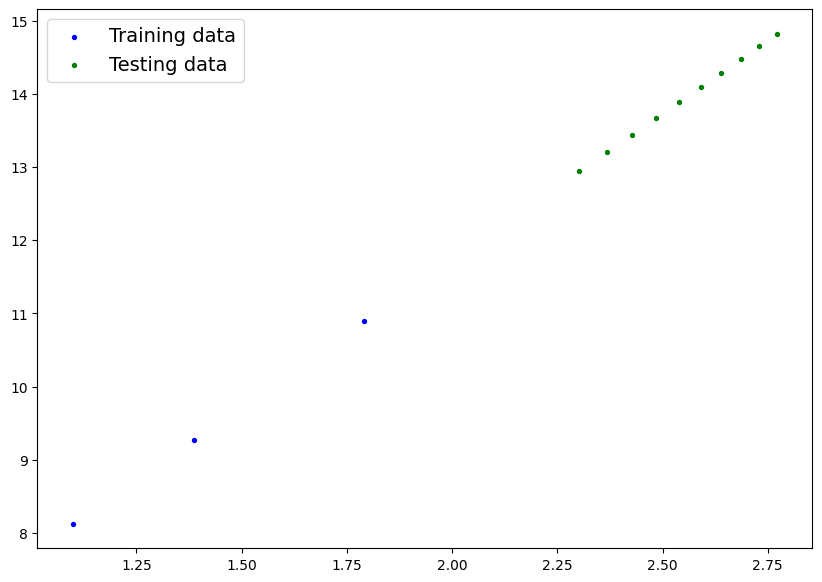

In [283]:
plot_predictions()

In [284]:
from torch import nn
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)

In [285]:
torch.manual_seed(42)

In [286]:
model_0 = LinearRegressionModel()
model_0
list(model_0.parameters())

[Parameter containing:
 tensor([[0.7645]], requires_grad=True),
 Parameter containing:
 tensor([0.8300], requires_grad=True)]

In [287]:
with torch.inference_mode():
  STR_preds = model_0(L_test.unsqueeze(1))

STR_preds

tensor([[2.5904],
        [2.6398],
        [2.6861],
        [2.7298],
        [2.7712],
        [2.8104],
        [2.8477],
        [2.8832],
        [2.9172],
        [2.9498]])

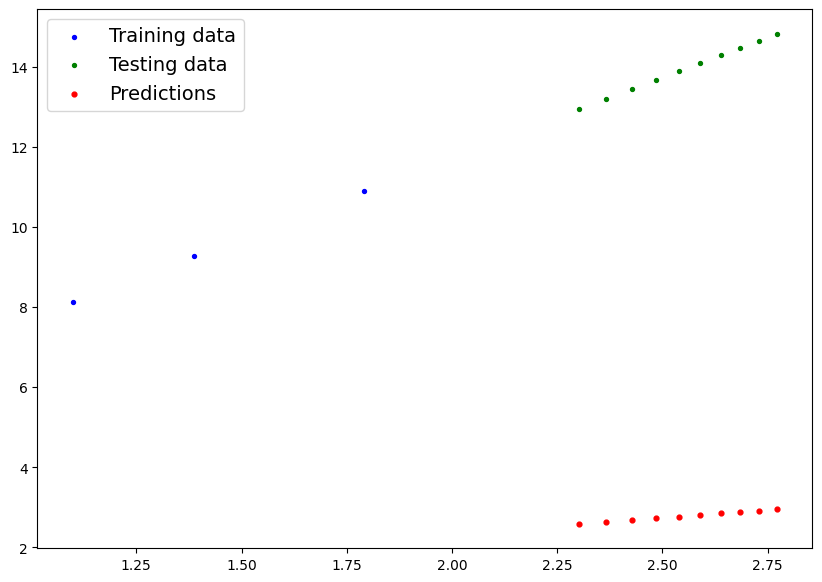

In [288]:
plot_predictions(predictions=STR_preds)

In [289]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(
    model_0.parameters(),
    lr=0.001,              # Learning rate
    weight_decay=0.1     # Ridge penalty (λ)
)

In [290]:
epochs = 10000
for epoch in range(epochs):
    # Training mode
    model_0.train()

    # Forward pass
    STR_pred = model_0(L_train.unsqueeze(1))
    loss = loss_fn(STR_pred, STR_train.unsqueeze(1))

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Evaluation mode
    model_0.eval()
    with torch.inference_mode():
        test_pred = model_0(L_test.unsqueeze(1))
        test_loss = loss_fn(test_pred, STR_ana_test.unsqueeze(1))

    # Print progress
    if epoch % 10 == 0:
     print(f" Epoch = {epoch:3d} | Loss : {loss:.4f} | Test_loss : {test_loss: .4f}")
     print(model_0.state_dict())

 Epoch =   0 | Loss : 57.2757 | Test_loss :  123.2615
OrderedDict({'linear.weight': tensor([[0.7864]]), 'linear.bias': tensor([0.8449])})
 Epoch =  10 | Loss : 50.6340 | Test_loss :  108.5300
OrderedDict({'linear.weight': tensor([[0.9976]]), 'linear.bias': tensor([0.9893])})
 Epoch =  20 | Loss : 44.7700 | Test_loss :  95.5502
OrderedDict({'linear.weight': tensor([[1.1960]]), 'linear.bias': tensor([1.1248])})
 Epoch =  30 | Loss : 39.5922 | Test_loss :  84.1144
OrderedDict({'linear.weight': tensor([[1.3822]]), 'linear.bias': tensor([1.2521])})
 Epoch =  40 | Loss : 35.0198 | Test_loss :  74.0396
OrderedDict({'linear.weight': tensor([[1.5571]]), 'linear.bias': tensor([1.3716])})
 Epoch =  50 | Loss : 30.9817 | Test_loss :  65.1642
OrderedDict({'linear.weight': tensor([[1.7213]]), 'linear.bias': tensor([1.4839])})
 Epoch =  60 | Loss : 27.4151 | Test_loss :  57.3458
OrderedDict({'linear.weight': tensor([[1.8755]]), 'linear.bias': tensor([1.5893])})
 Epoch =  70 | Loss : 24.2646 | Test_lo

In [291]:
STR_preds_new = model_0(L_test.unsqueeze(1))

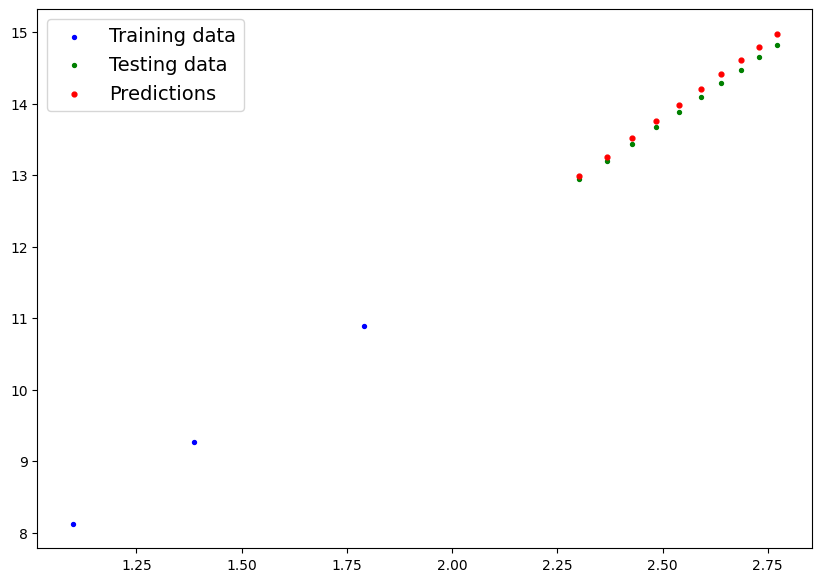

In [292]:
plot_predictions(predictions=STR_preds_new.detach().squeeze())

In [293]:
STR_preds_new

tensor([[12.9864],
        [13.2599],
        [13.5168],
        [13.7590],
        [13.9881],
        [14.2054],
        [14.4122],
        [14.6093],
        [14.7977],
        [14.9780]], grad_fn=<AddmmBackward0>)

In [294]:
exp_STR_preds =torch.exp(STR_preds_new.detach().squeeze())
exp_STR_preds

tensor([ 436430.9062,  573701.6875,  741743.6250,  945023.8750, 1188345.2500,
        1476856.2500, 1816046.2500, 2211761.2500, 2670194.2500, 3197904.7500])

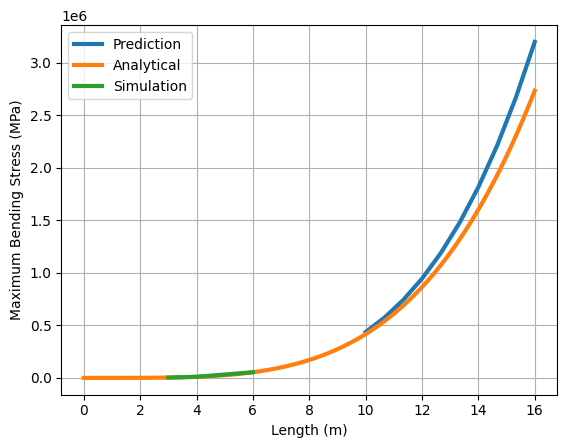

In [295]:
import matplotlib.pyplot as plt
import numpy as np
L1 = np.linspace(0, 16, 1000)
Stress_A = 41.7 * (L1**4)
L2 =  np.array([6, 4, 3])
Stress_S = np.array([54000, 10667, 3375])
plt.plot(l_test, exp_STR_preds, linewidth =3)
plt.plot(L1, Stress_A, linewidth=3)
plt.plot(L2, Stress_S, linewidth=3)
plt.xlabel("Length (m)")
plt.ylabel("Maximum Bending Stress (MPa)")
plt.legend(["Prediction","Analytical", "Simulation"])
plt.grid(True)
plt.show()